# 03 — Survival model + baseline comparison

This produces the numbers for your evaluation slide and IDF Section 8, Experiment 1:
- Cox survival model concordance index (censoring-aware, retains ALL companies)
- Naive fixed-horizon logistic regression AUC (the prior-art approach, which deletes still-operating companies)
- A Kaplan-Meier chart by sector — your one visual for the review

Reads: `data/processed/outcomes.csv`
Writes: `models/cox_model.pkl`, `data/processed/survival_scored.csv`, `reports/km_by_sector.png`

In [1]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import joblib
import os
import matplotlib.pyplot as plt

PROCESSED = "../data/processed"
MODELS = "../models"
REPORTS = "../reports"
os.makedirs(MODELS, exist_ok=True)

df = pd.read_csv(f"{PROCESSED}/outcomes.csv")
print(f"[load] {len(df)} companies")
df.head()

[load] 98280 companies


,id,name,category_code,country_code,status,funding_total_usd,funding_rounds,duration_months,event
0,c:1,Wetpaint,web,USA,operating,39750000.0,3,67.017083,1
1,c:10000,MYWEBBO,network_hosting,NaN,operating,0.0,0,64.553219,0
2,c:10001,THE Movie Streamer,games_video,NaN,operating,0.0,0,64.553219,0
3,c:10002,Synergie Media,advertising,MAR,operating,0.0,0,77.529566,0
4,c:10003,Green Basti Ecosystems,cleantech,IND,operating,0.0,0,63.731932,0


## Build features

In [2]:
feat = df[["id", "duration_months", "event", "funding_total_usd", "funding_rounds", "category_code"]].copy()
feat["funding_total_usd"] = feat["funding_total_usd"].fillna(0)
feat["funding_rounds"] = feat["funding_rounds"].fillna(0)
feat["log_funding"] = np.log1p(feat["funding_total_usd"])

top_sectors = feat["category_code"].value_counts().head(8).index
feat["sector"] = feat["category_code"].where(feat["category_code"].isin(top_sectors), "other")
feat = pd.get_dummies(feat, columns=["sector"], drop_first=True)
feat = feat.drop(columns=["category_code", "funding_total_usd"]).dropna()
print(f"[features] {feat.shape[1]-3} features, {len(feat)} companies after dropping NaNs")
feat.head()

[features] 9 features, 98280 companies after dropping NaNs


,id,duration_months,event,funding_rounds,log_funding,sector_consulting,sector_ecommerce,sector_games_video,sector_mobile,sector_other,sector_software,sector_web
0,c:1,67.017083,1,3,17.49812,False,False,False,False,False,False,True
1,c:10000,64.553219,0,0,0.00000,False,False,False,False,True,False,False
2,c:10001,64.553219,0,0,0.00000,False,False,True,False,False,False,False
3,c:10002,77.529566,0,0,0.00000,False,False,False,False,False,False,False
4,c:10003,63.731932,0,0,0.00000,False,False,False,False,True,False,False


## Fit the Cox survival model (retains every company, including still-operating ones)

In [3]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(feat.drop(columns=["id"]), duration_col="duration_months", event_col="event")
cph.print_summary()

c_index = concordance_index(feat["duration_months"], -cph.predict_partial_hazard(feat), feat["event"])
print(f"\n[survival] concordance index = {c_index:.3f}   <-- cite this in Section 8 / eval slide")

surv_func = cph.predict_survival_function(feat, times=[6, 12])
feat["p_exhaust_6m"] = 1 - surv_func.loc[6].values
feat["p_exhaust_12m"] = 1 - surv_func.loc[12].values

joblib.dump(cph, f"{MODELS}/cox_model.pkl")
print(f"[saved] {MODELS}/cox_model.pkl")

<lifelines.CoxPHFitter: fitted with 98280 total observations, 88852 right-censored observations>
             duration col = 'duration_months'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 98280
number of events observed = 9428
   partial log-likelihood = -96537.22
         time fit was run = 2026-08-30 16:53:47 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
funding_rounds      0.05      1.06      0.01            0.04            0.07                1.04                1.07
log_funding         0.08      1.08      0.00            0.08            0.08                1.08                1.08
sector_consulting  -0.31      0.73      0.04           -0.39           -0.23                0.68                0.79
sector_ecommerce   -0.06      0.95      0.03           -0.11            0.00                0.89                1.00
sector_games_video  0.21      1.24      0.03            0.15            0.28                1.16                1.32
sector_mobile       0.11      1.11      0.03            0.04            0.17                1.04                1.19
sector_other       -0.07      0.93      0.02           -0.10           -0.04                0.90                0.96
sector_software    -0.02      0.98      0.02           -0.06            0.02                0.94                1.02
sector_web          0.28      1.32      0.02            0.23            0.32                1.26                1.38

                    cmp to     z      p  -log2(p)
covariate                                        
funding_rounds        0.00  9.30 <0.005     65.94
log_funding           0.00 69.73 <0.005       inf
sector_consulting     0.00 -7.74 <0.005     46.47
sector_ecommerce      0.00 -1.85   0.06      3.95
sector_games_video    0.00  6.40 <0.005     32.61
sector_mobile         0.00  3.24 <0.005      9.71
sector_other          0.00 -4.70 <0.005     18.58
sector_software       0.00 -0.95   0.34      1.56
sector_web            0.00 11.95 <0.005    107.00
---
Concordance = 0.77
Partial AIC = 193092.44
log-likelihood ratio test = 6988.01 on 9 df
-log2(p) of ll-ratio test = inf


[survival] concordance index = 0.769   <-- cite this in Section 8 / eval slide
[saved] ../models/cox_model.pkl


## Baseline: naive fixed-horizon logistic regression

This is the prior-art approach — deletes any company that hasn't been
observed for a full 12 months, which is most of the still-operating ones.
The comparison here IS your Experiment 2.

In [4]:
labeled = feat[(feat["event"] == 1) | (feat["duration_months"] >= 12)].copy()
labeled["failed_12m"] = ((labeled["event"] == 1) & (labeled["duration_months"] <= 12)).astype(int)

drop_cols = ["id", "duration_months", "event", "p_exhaust_6m", "p_exhaust_12m", "failed_12m"]
X = labeled.drop(columns=[c for c in drop_cols if c in labeled.columns])
y = labeled["failed_12m"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
discarded = len(feat) - len(labeled)

print(f"[baseline] fixed-horizon logistic regression AUC @ 12mo = {auc:.3f}")
print(f"[baseline] discards {discarded} still-operating, <12mo-observed companies "
      f"({100*discarded/len(feat):.1f}%) that the survival model retains as censored")

[baseline] fixed-horizon logistic regression AUC @ 12mo = 0.667
[baseline] discards 7606 still-operating, <12mo-observed companies (7.7%) that the survival model retains as censored


## Does the model generalize across sectors? (answers your guide's question directly)

In [5]:
sector_cols = [c for c in feat.columns if c.startswith("sector_")]
print(f"{'sector':20s} {'n':>6s} {'c-index':>10s}")
for col in sector_cols:
    g = feat[feat[col] == 1]
    if len(g) < 30:
        continue
    try:
        ci = concordance_index(g["duration_months"], -cph.predict_partial_hazard(g), g["event"])
        print(f"{col.replace('sector_',''):20s} {len(g):6d} {ci:10.3f}")
    except Exception as e:
        print(f"{col.replace('sector_',''):20s} {len(g):6d}      skip ({e})")
print("\nIf C-index holds up (doesn't collapse toward 0.5) across sectors, that's your evidence")
print("the model isn't just fitting one type of company — exactly what your guide asked about.")

sector                    n    c-index
consulting             3923      0.911
ecommerce              7587      0.828
games_video            5053      0.802
mobile                 5433      0.709
other                 43304      0.755
software              15238      0.796
web                   12625      0.797

If C-index holds up (doesn't collapse toward 0.5) across sectors, that's your evidence
the model isn't just fitting one type of company — exactly what your guide asked about.


## Kaplan-Meier chart — your one visual for the review

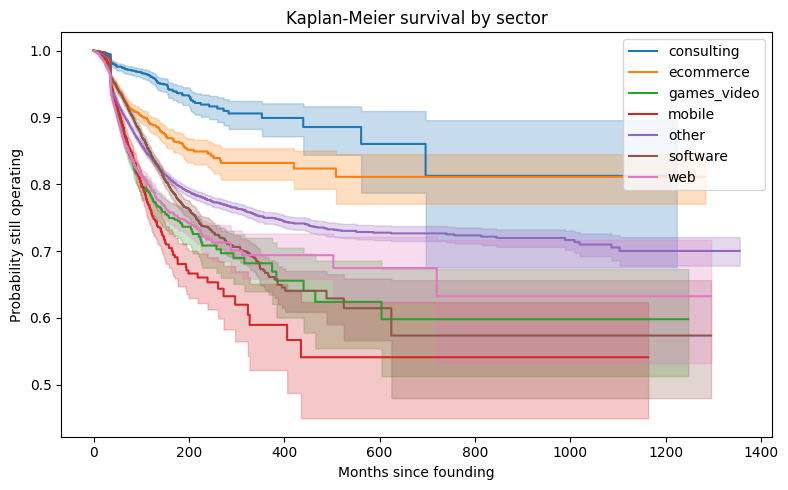

[saved] ../reports/km_by_sector.png


In [6]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8, 5))
for col in sector_cols:
    g = feat[feat[col] == 1]
    if len(g) < 15:
        continue
    kmf.fit(g["duration_months"], g["event"], label=col.replace("sector_", ""))
    kmf.plot_survival_function(ax=ax)
ax.set_xlabel("Months since founding")
ax.set_ylabel("Probability still operating")
ax.set_title("Kaplan-Meier survival by sector")
plt.tight_layout()
plt.savefig(f"{REPORTS}/km_by_sector.png", dpi=150)
plt.show()
print(f"[saved] {REPORTS}/km_by_sector.png")

In [7]:
feat.to_csv(f"{PROCESSED}/survival_scored.csv", index=False)
print(f"[done] wrote {PROCESSED}/survival_scored.csv")
print(f"\n=== SUMMARY FOR YOUR SLIDE ===")
print(f"Concordance index (Cox, censoring-aware): {c_index:.3f}")
print(f"AUC @ 12mo (naive logistic baseline):      {auc:.3f}")
print(f"Companies retained by survival model:       {len(feat)}")
print(f"Companies discarded by naive baseline:      {discarded} ({100*discarded/len(feat):.1f}%)")

[done] wrote ../data/processed/survival_scored.csv

=== SUMMARY FOR YOUR SLIDE ===
Concordance index (Cox, censoring-aware): 0.769
AUC @ 12mo (naive logistic baseline):      0.667
Companies retained by survival model:       98280
Companies discarded by naive baseline:      7606 (7.7%)
